Imports & load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Plot styling — consistent across all charts
plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'font.size'         : 11,
})

df = pd.read_csv('../data/online_retail_clean.csv', parse_dates=['invoicedate'])

# Useful time columns
df['year']        = df['invoicedate'].dt.year
df['month']       = df['invoicedate'].dt.month
df['month_name']  = df['invoicedate'].dt.strftime('%b')
df['day_of_week'] = df['invoicedate'].dt.day_name()
df['hour']        = df['invoicedate'].dt.hour
df['year_month']  = df['invoicedate'].dt.to_period('M').astype(str)

print(f"Data loaded: {len(df):,} rows ✓")
print(f"Date range: {df['invoicedate'].min().date()} → {df['invoicedate'].max().date()}")

Data loaded: 802,932 rows ✓
Date range: 2009-12-01 → 2011-12-09


Chart 1: Monthly revenue trend with year-over-year comparison

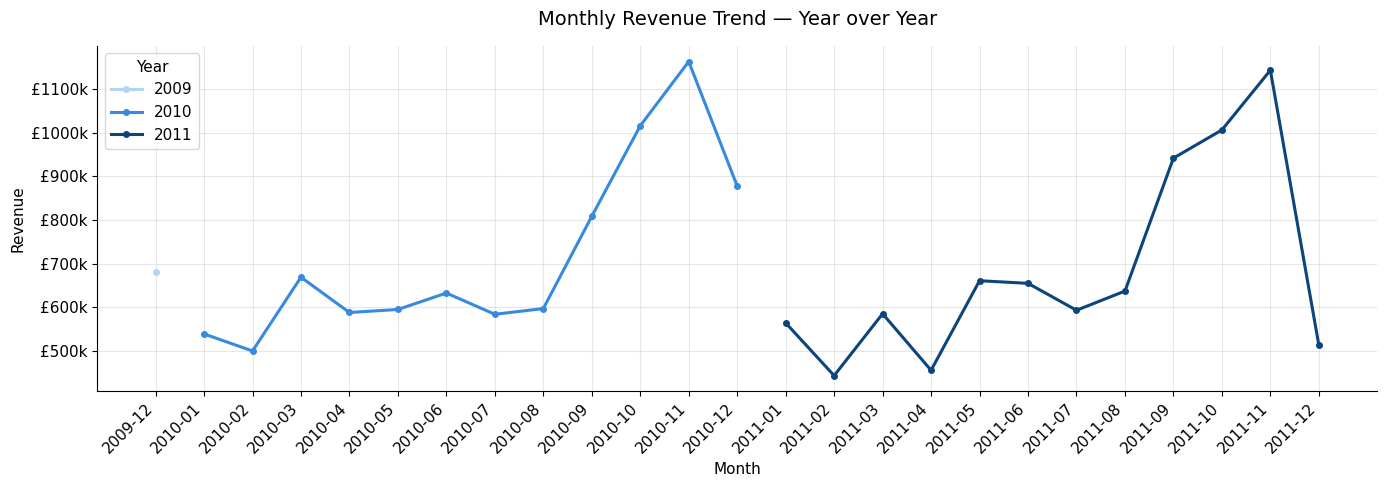

Chart 1 saved ✓


In [2]:
monthly = (df.groupby(['year', 'year_month'])
             .agg(revenue=('revenue', 'sum'),
                  orders=('invoice', 'nunique'))
             .reset_index()
             .sort_values('year_month'))

fig, ax = plt.subplots(figsize=(14, 5))

colors = {2009: '#B5D4F4', 2010: '#378ADD', 2011: '#0C447C'}

for year, group in monthly.groupby('year'):
    ax.plot(group['year_month'], group['revenue'],
            marker='o', linewidth=2.2, markersize=4,
            label=str(year), color=colors[year])

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
ax.set_title('Monthly Revenue Trend — Year over Year', fontsize=14, pad=15)
ax.legend(title='Year')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/figures/monthly_revenue_yoy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved ✓")

Chart 2: Revenue heatmap by day of week × hour

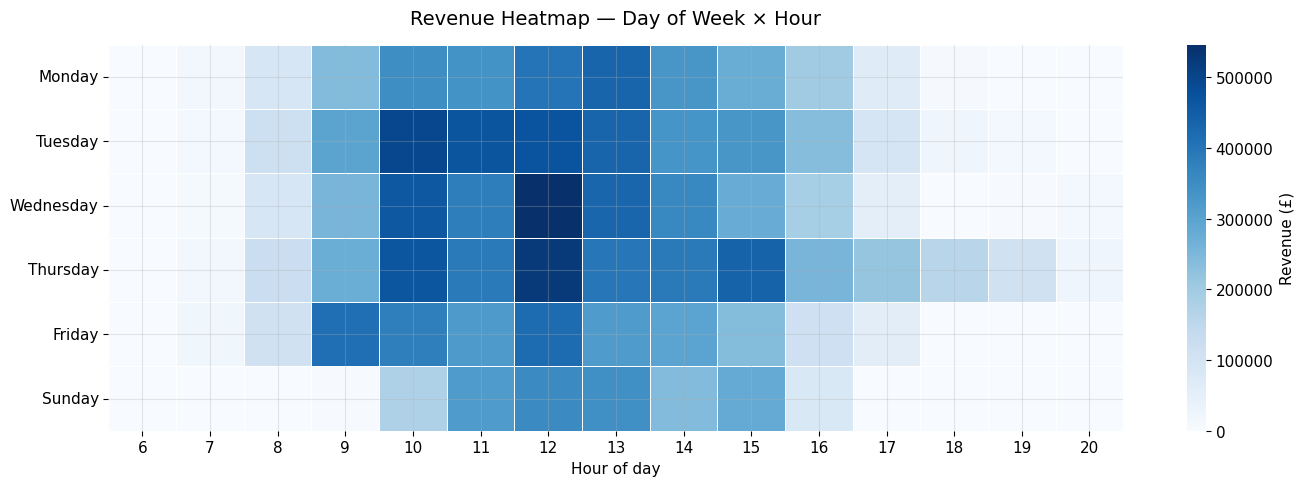

Chart 2 saved ✓


In [3]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Sunday']

heatmap_data = (df.groupby(['day_of_week', 'hour'])['revenue']
                  .sum()
                  .unstack(fill_value=0))

# Reorder rows
heatmap_data = heatmap_data.reindex([d for d in dow_order
                                     if d in heatmap_data.index])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data,
            cmap='Blues',
            fmt='.0f',
            linewidths=0.4,
            ax=ax,
            cbar_kws={'label': 'Revenue (£)'})

ax.set_title('Revenue Heatmap — Day of Week × Hour', fontsize=14, pad=15)
ax.set_xlabel('Hour of day')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../outputs/figures/revenue_heatmap_dow_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved ✓")

Chart 3: Pareto chart — top 20 products by revenue

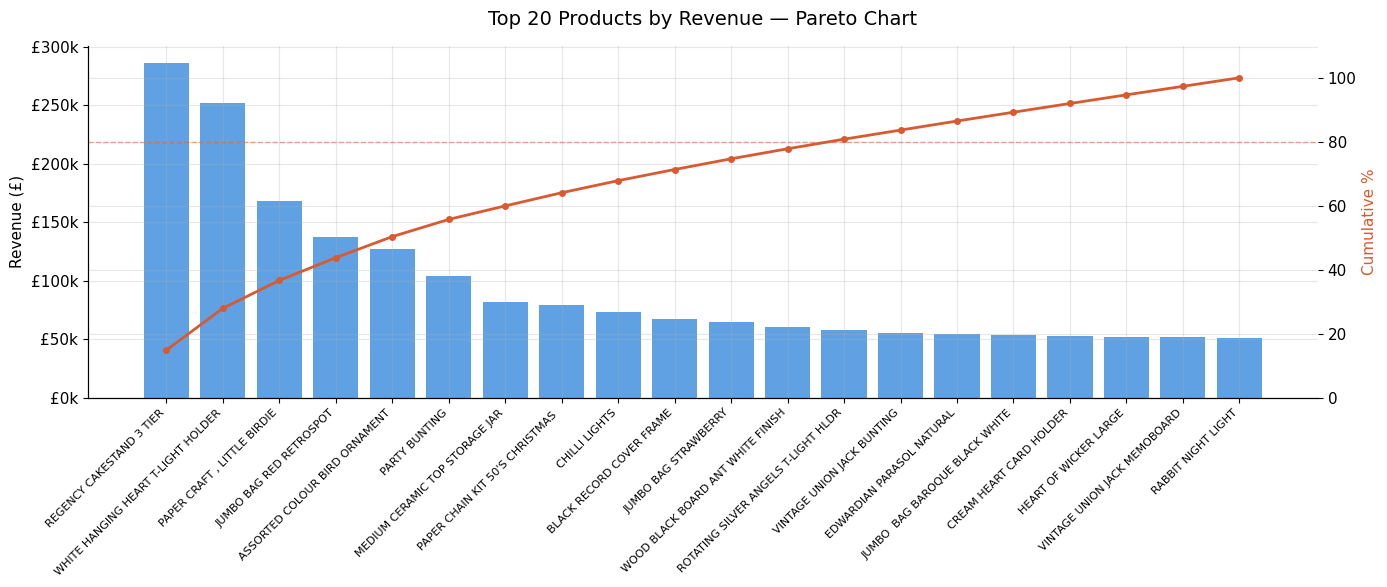

Chart 3 saved ✓


In [4]:
top_products = (df.groupby('description')['revenue']
                  .sum()
                  .sort_values(ascending=False)
                  .head(20)
                  .reset_index())

top_products['cumulative_pct'] = (top_products['revenue'].cumsum()
                                  / top_products['revenue'].sum() * 100)

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(range(len(top_products)), top_products['revenue'],
        color='#378ADD', alpha=0.8)
ax1.set_xticks(range(len(top_products)))
ax1.set_xticklabels(top_products['description'],
                    rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Revenue (£)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))

ax2 = ax1.twinx()
ax2.plot(range(len(top_products)), top_products['cumulative_pct'],
         color='#D85A30', marker='o', markersize=4, linewidth=2)
ax2.set_ylabel('Cumulative %', color='#D85A30')
ax2.axhline(y=80, color='#D85A30', linestyle='--', alpha=0.5, linewidth=1)
ax2.set_ylim(0, 110)

ax1.set_title('Top 20 Products by Revenue — Pareto Chart', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../outputs/figures/pareto_top_products.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved ✓")

Chart 4: Customer purchase frequency distribution

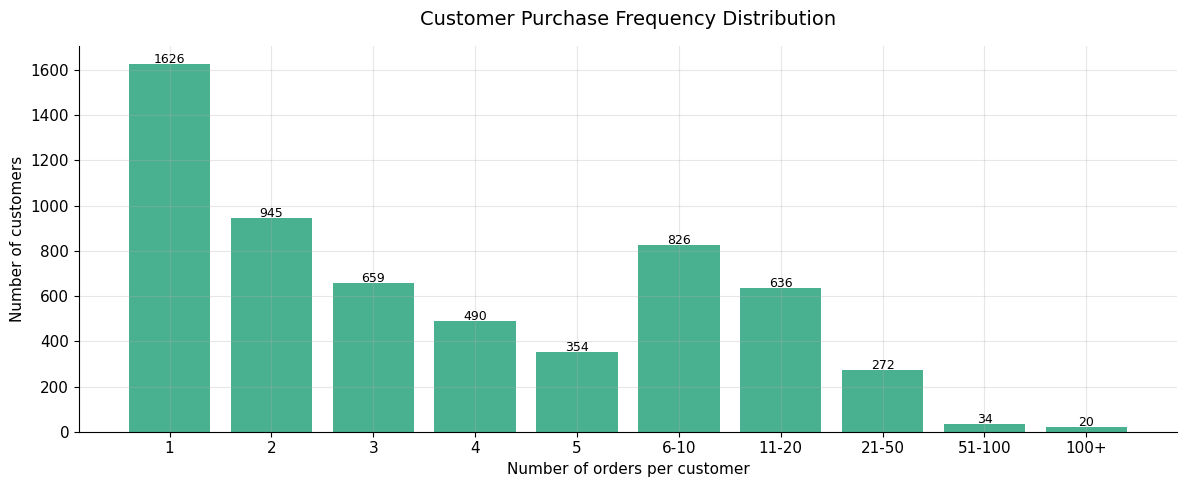

Chart 4 saved ✓


In [5]:
purchase_freq = (df.groupby('customer_id')['invoice']
                   .nunique()
                   .reset_index()
                   .rename(columns={'invoice': 'num_orders'}))

fig, ax = plt.subplots(figsize=(12, 5))

bins = [1,2,3,4,5,6,10,20,50,100,purchase_freq['num_orders'].max()+1]
labels = ['1','2','3','4','5','6-10','11-20','21-50','51-100','100+']

purchase_freq['bucket'] = pd.cut(purchase_freq['num_orders'],
                                  bins=bins, labels=labels, right=False)

bucket_counts = purchase_freq['bucket'].value_counts().reindex(labels)

ax.bar(labels, bucket_counts.values, color='#1D9E75', alpha=0.8)
ax.set_xlabel('Number of orders per customer')
ax.set_ylabel('Number of customers')
ax.set_title('Customer Purchase Frequency Distribution', fontsize=14, pad=15)

for i, v in enumerate(bucket_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/purchase_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved ✓")

Chart 5: Revenue distribution per order

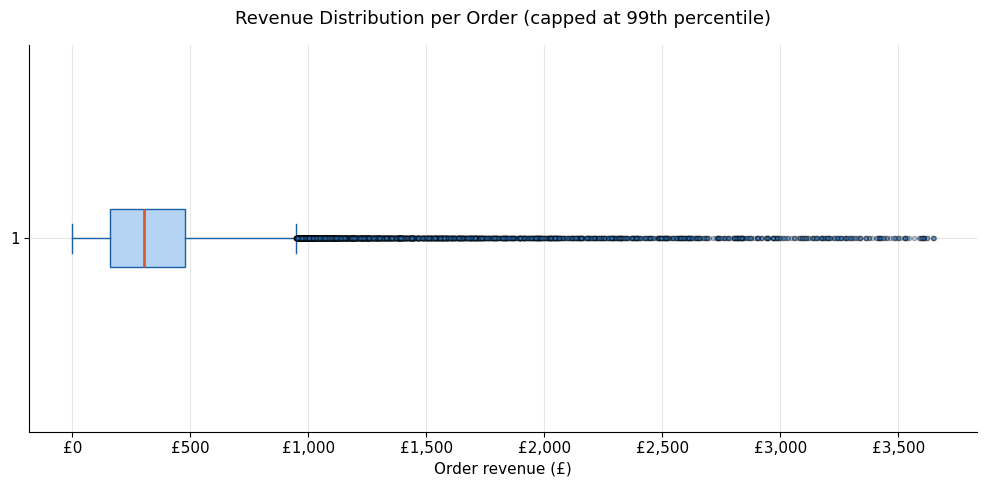

Median order value:  £303.38
Mean order value:    £399.11
Std deviation:       £410.68
Chart 5 saved ✓


In [6]:
order_revenue = (df.groupby(['customer_id', 'invoice'])['revenue']
                   .sum()
                   .reset_index())

# Cap at 99th percentile to remove extreme outliers for visualization
cap = order_revenue['revenue'].quantile(0.99)
order_rev_capped = order_revenue[order_revenue['revenue'] <= cap]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(order_rev_capped['revenue'],
           vert=False,
           patch_artist=True,
           boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
           medianprops=dict(color='#D85A30', linewidth=2),
           whiskerprops=dict(color='#185FA5'),
           capprops=dict(color='#185FA5'),
           flierprops=dict(marker='o', markerfacecolor='#378ADD',
                           alpha=0.3, markersize=3))

ax.set_xlabel('Order revenue (£)')
ax.set_title('Revenue Distribution per Order (capped at 99th percentile)', fontsize=13, pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('../outputs/figures/order_revenue_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Median order value:  £{order_rev_capped['revenue'].median():,.2f}")
print(f"Mean order value:    £{order_rev_capped['revenue'].mean():,.2f}")
print(f"Std deviation:       £{order_rev_capped['revenue'].std():,.2f}")
print("Chart 5 saved ✓")

Chart 6: Cohort retention analysis

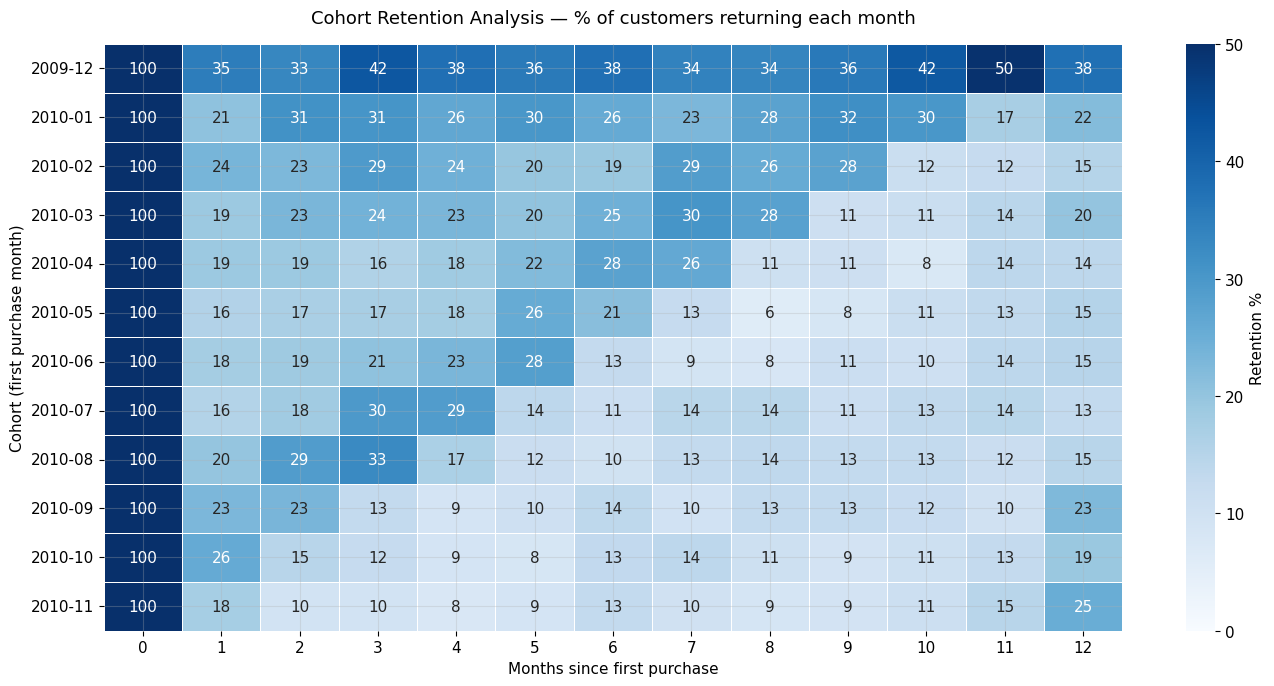

Chart 6 saved ✓


In [7]:
# Get each customer's first purchase month
df['order_month'] = df['invoicedate'].dt.to_period('M')

cohort_data = df.groupby('customer_id')['order_month'].min().reset_index()
cohort_data.columns = ['customer_id', 'cohort_month']

df_cohort = df.merge(cohort_data, on='customer_id')
df_cohort['period_number'] = (df_cohort['order_month']
                               - df_cohort['cohort_month']).apply(lambda x: x.n)

cohort_pivot = (df_cohort.groupby(['cohort_month', 'period_number'])['customer_id']
                          .nunique()
                          .unstack(fill_value=0))

cohort_size  = cohort_pivot.iloc[:, 0]
retention    = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

# Plot only first 12 periods and first 12 cohorts for readability
retention_plot = retention.iloc[:12, :13]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(retention_plot,
            annot=True,
            fmt='.0f',
            cmap='Blues',
            ax=ax,
            vmin=0, vmax=50,
            linewidths=0.4,
            cbar_kws={'label': 'Retention %'})

ax.set_title('Cohort Retention Analysis — % of customers returning each month',
             fontsize=13, pad=15)
ax.set_xlabel('Months since first purchase')
ax.set_ylabel('Cohort (first purchase month)')
plt.tight_layout()
plt.savefig('../outputs/figures/cohort_retention.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved ✓")